# 05 — Final Model & Predictions
## FMD Outbreak Prediction — Sri Lanka (2024)

**Objective:** Train the best model from Notebook 04 on all available
historical data (2017–2023) and generate detailed predictions for 2024.

This notebook produces:
1. Classification report and confusion matrix
2. Actual vs Predicted outbreak heatmap
3. Outbreak probability heatmap
4. District risk ranking
5. Saved trained model file

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, precision_score, recall_score)

BASE_DIR  = r'D:\\Projects\\Research_Component'
DATA_FILE = os.path.join(BASE_DIR, 'data', 'processed',
                         'FMD_model_ready_main refined_final_dataset.csv')
PLOT_DIR  = os.path.join(BASE_DIR, 'plots', '05_final_predictions')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)

# Prepare features (same as Notebook 04)
le = LabelEncoder()
df['district_enc'] = le.fit_transform(df['district'])
TARGET = 'Outbreak status'
drop_cols = ['year', 'month_num', 'district', 'PCODE', 'district_enc', TARGET]
feature_cols = [c for c in df.columns if c not in drop_cols]

print(f"Dataset: {df.shape}")
print(f"Features: {len(feature_cols)}")

Dataset: (2400, 27)
Features: 22


---
## Step 1: Train Final Model

We train on **2017–2023** (7 years) and test on **2024**.
Based on Notebook 04 results, we use Logistic Regression with
balanced class weights.

In [ ]:
train = df[df['year'] < 2024]
test  = df[df['year'] == 2024].copy()

X_train, y_train = train[feature_cols], train[TARGET]
X_test,  y_test  = test[feature_cols],  test[TARGET]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced',
                           random_state=42)
model.fit(X_train_s, y_train)

test['pred'] = model.predict(X_test_s)
test['prob'] = model.predict_proba(X_test_s)[:, 1]

print(f"Training set: {len(train)} rows (2017–2023)")
print(f"Test set:     {len(test)} rows (2024)")

Training set: 2100 rows (2017–2023)
Test set:     300 rows (2024)


---
## Step 2: Classification Report

In [ ]:
print("="*60)
print("  Classification Report — 2024 Predictions")
print("="*60)
print(classification_report(y_test, test['pred'],
                            target_names=['No Outbreak', 'Outbreak'],
                            zero_division=0))

prec = precision_score(y_test, test['pred'], zero_division=0)
rec  = recall_score(y_test, test['pred'], zero_division=0)
f1   = f1_score(y_test, test['pred'], zero_division=0)
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 Score:  {f1:.3f}")

  Classification Report — 2024 Predictions
              precision    recall  f1-score   support

 No Outbreak       0.89      0.77      0.83       222
    Outbreak       0.53      0.73      0.61        78

    accuracy                           0.76       300
   macro avg       0.71      0.75      0.72       300
weighted avg       0.80      0.76      0.77       300

Precision: 0.528
Recall:    0.731
F1 Score:  0.613


---
## Step 3: Confusion Matrix

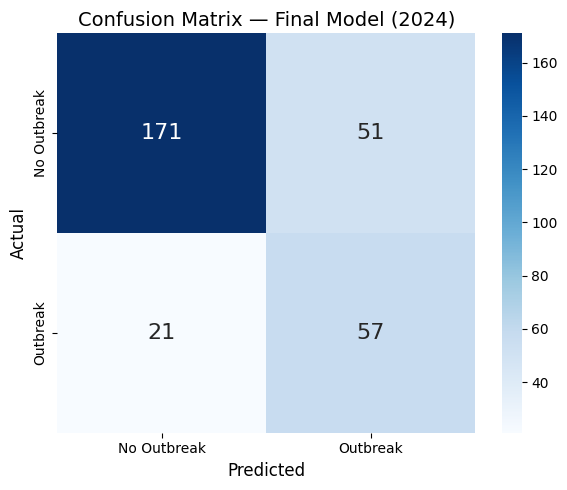

✅ Saved!


In [ ]:
cm = confusion_matrix(y_test, test['pred'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Outbreak', 'Outbreak'],
            yticklabels=['No Outbreak', 'Outbreak'], ax=ax,
            annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Final Model (2024)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print("✅ Saved!")

---
## Step 4: Actual vs Predicted Heatmap

This side-by-side heatmap shows every district-month in 2024,
comparing actual outbreaks with model predictions.

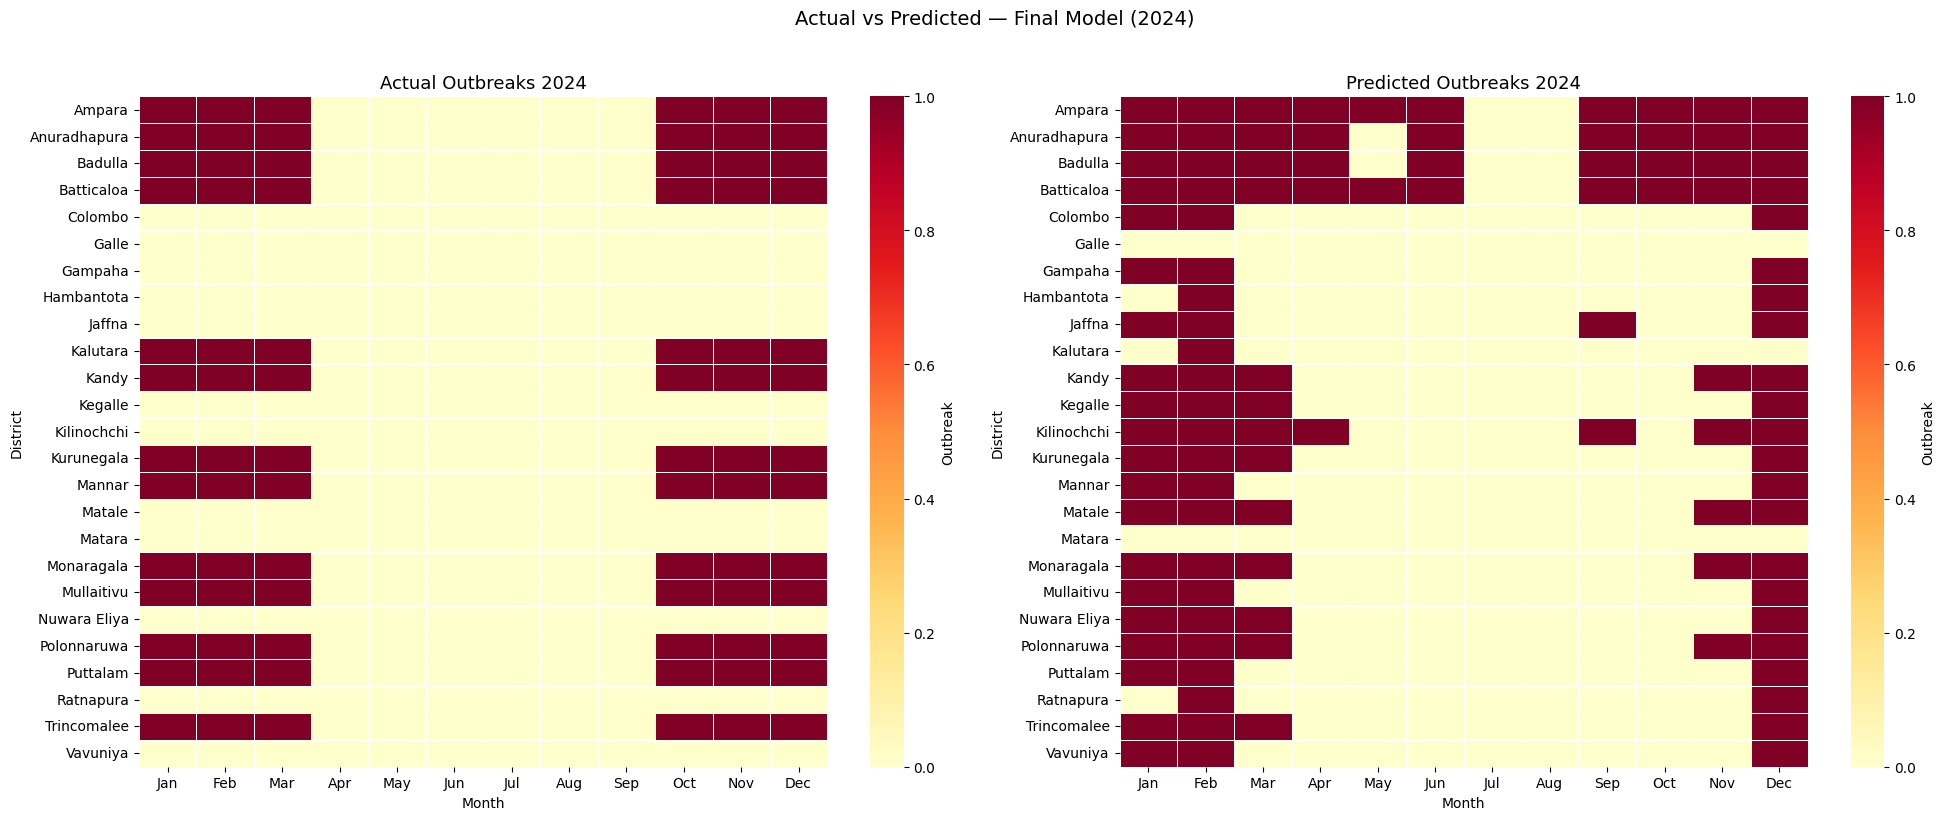

✅ Saved!


In [ ]:
districts_sorted = sorted(test['district'].unique())
months = list(range(1, 13))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

actual_mat = np.zeros((len(districts_sorted), 12))
pred_mat   = np.zeros((len(districts_sorted), 12))

for i, dist in enumerate(districts_sorted):
    for j, m in enumerate(months):
        row = test[(test['district'] == dist) & (test['month_num'] == m)]
        if len(row) > 0:
            actual_mat[i, j] = row.iloc[0][TARGET]
            pred_mat[i, j]   = row.iloc[0]['pred']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(actual_mat, ax=axes[0], cmap='YlOrRd',
            cbar_kws={'label': 'Outbreak'},
            xticklabels=month_labels, yticklabels=districts_sorted,
            linewidths=0.5, vmin=0, vmax=1)
axes[0].set_title('Actual Outbreaks 2024', fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('District')

sns.heatmap(pred_mat, ax=axes[1], cmap='YlOrRd',
            cbar_kws={'label': 'Outbreak'},
            xticklabels=month_labels, yticklabels=districts_sorted,
            linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Predicted Outbreaks 2024', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('District')

plt.suptitle('Actual vs Predicted — Final Model (2024)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'actual_vs_predicted.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

---
## Step 5: Outbreak Probability Heatmap

Instead of just 0/1 predictions, this shows the model's **confidence**
for each district-month. Higher values = higher outbreak risk.

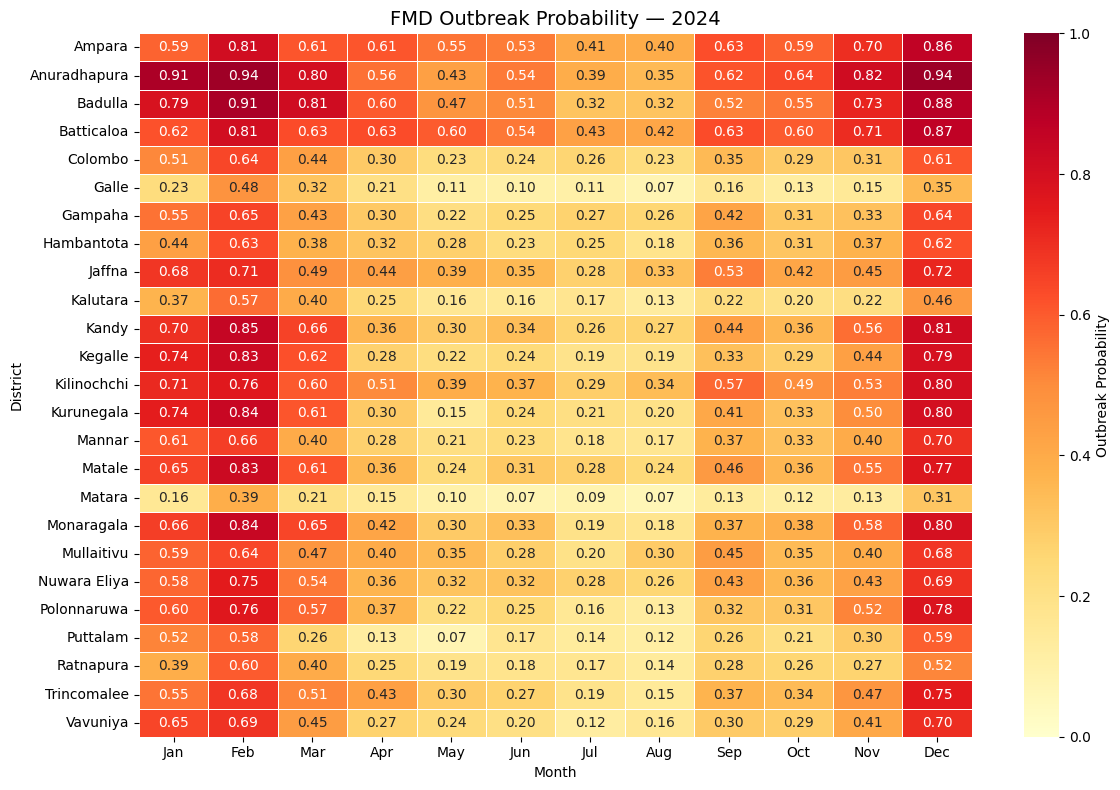

✅ Saved!


In [ ]:
prob_mat = np.zeros((len(districts_sorted), 12))
for i, dist in enumerate(districts_sorted):
    for j, m in enumerate(months):
        row = test[(test['district'] == dist) & (test['month_num'] == m)]
        if len(row) > 0:
            prob_mat[i, j] = row.iloc[0]['prob']

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(prob_mat, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
            xticklabels=month_labels, yticklabels=districts_sorted,
            linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Outbreak Probability'})
ax.set_title('FMD Outbreak Probability — 2024', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('District')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'outbreak_probability.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

---
## Step 6: District Risk Ranking

Rank districts by their **mean outbreak probability** in 2024.

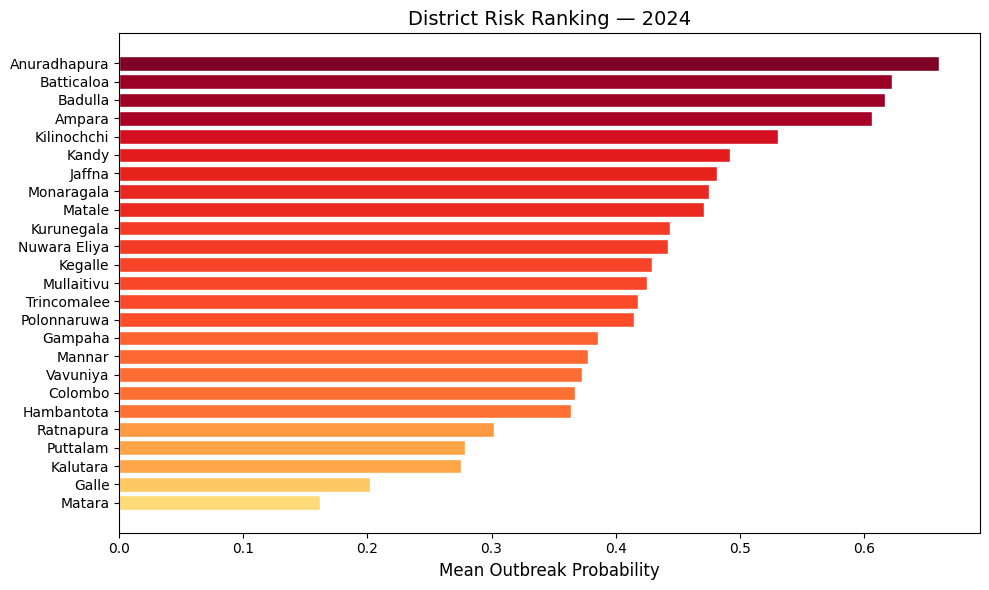

✅ Saved!


In [ ]:
district_risk = test.groupby('district')['prob'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.YlOrRd(district_risk.values / max(district_risk.values.max(), 0.01))
ax.barh(district_risk.index, district_risk.values,
        color=colors, edgecolor='white')
ax.set_xlabel('Mean Outbreak Probability', fontsize=12)
ax.set_title('District Risk Ranking — 2024', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'district_risk_ranking.png'), dpi=150)
plt.show()
print("✅ Saved!")

---
## Step 7: Save Trained Model

Save the trained model and scaler so they can be loaded later
without retraining.

In [ ]:
model_path  = os.path.join(MODEL_DIR, 'final_model_stage1.pkl')
scaler_path = os.path.join(MODEL_DIR, 'scaler_stage1.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(model, f)
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"✅ Model saved: {model_path}")
print(f"✅ Scaler saved: {scaler_path}")

✅ Model saved: ..\models\final_model_stage1.pkl
✅ Scaler saved: ..\models\scaler_stage1.pkl


---
## Step 8: Next-Month Forecast

This section turns the trained model into a one-step-ahead forecast tool.
It uses the latest available district record as the starting point and rolls
the month forward by one. The weather values are used as a persistence proxy,
so for a true operational forecast you should replace them with the latest
observed or forecasted weather inputs.

Next-month scenario forecast for Jan 2025
Using the latest observed district record as the base and rolling the month forward by one.
Replace the weather proxy values with real next-month weather forecasts for operational use.


,district,forecast_year,forecast_month_name,prediction,probability
0,Anuradhapura,2025,Jan,1,0.943043
1,Badulla,2025,Jan,1,0.888588
2,Batticaloa,2025,Jan,1,0.884868
3,Ampara,2025,Jan,1,0.878660
4,Kilinochchi,2025,Jan,1,0.830606
5,Monaragala,2025,Jan,1,0.813804
6,Kandy,2025,Jan,1,0.802098
7,Polonnaruwa,2025,Jan,1,0.793537
8,Matale,2025,Jan,1,0.791648
9,Trincomalee,2025,Jan,1,0.791303


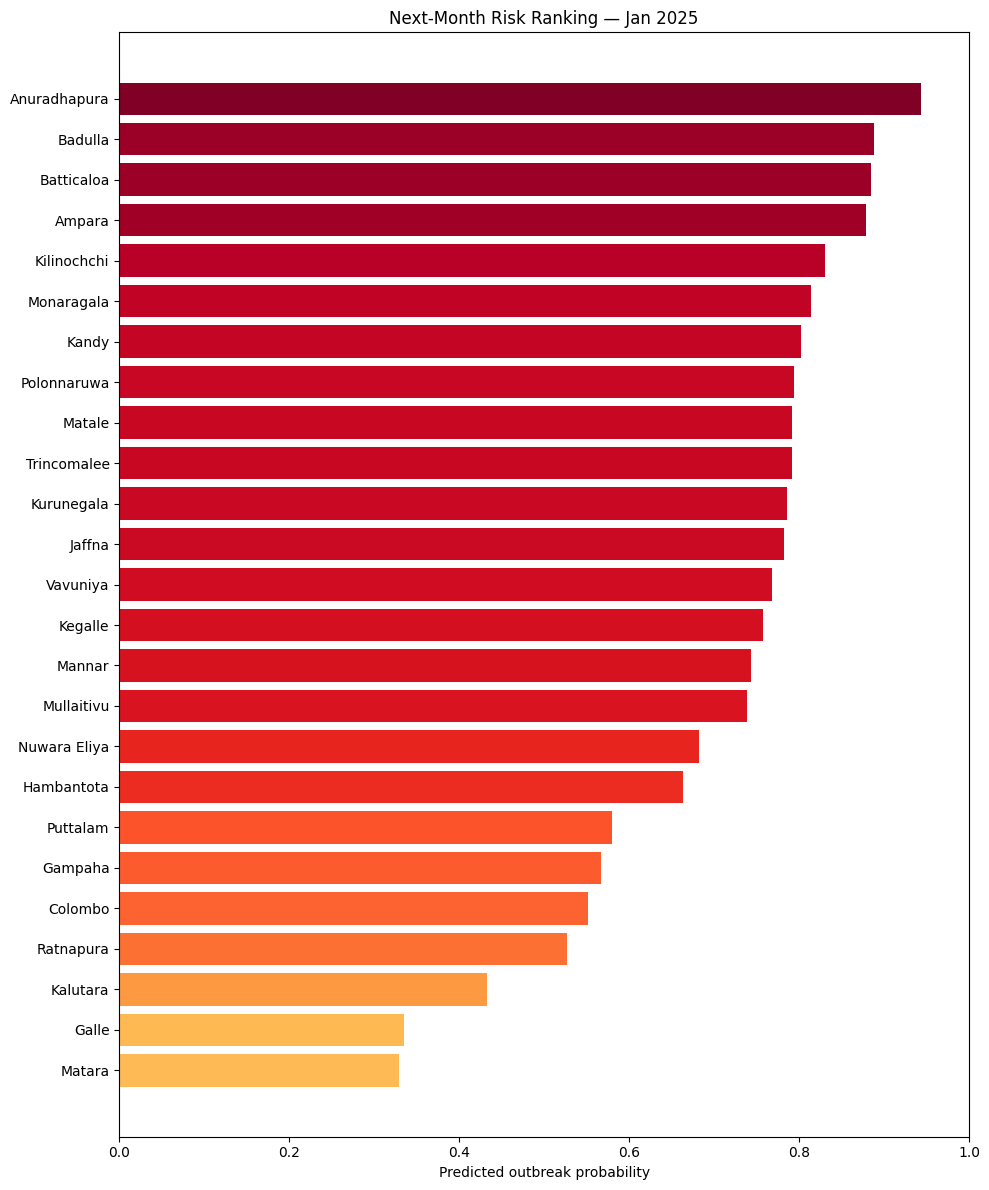

✅ Saved next-month forecast table and ranking plot (all districts).


In [ ]:
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

def get_next_month(year, month):
    if month == 12:
        return year + 1, 1
    return year, month + 1

latest_rows = (
    df.sort_values(['district', 'year', 'month_num'])
      .groupby('district', as_index=False)
      .tail(1)
      .copy()
 )

forecast_rows = []

for _, row in latest_rows.iterrows():
    forecast_year, forecast_month = get_next_month(int(row['year']), int(row['month_num']))
    future = row.copy()
    future['year'] = forecast_year
    future['month_num'] = forecast_month

    future['sin_month'] = np.sin(2 * np.pi * forecast_month / 12)
    future['cos_month'] = np.cos(2 * np.pi * forecast_month / 12)
    future['monsoon_phase_First_Inter_Monsoon'] = 1 if forecast_month in [3, 4] else 0
    future['monsoon_phase_SW_Monsoon'] = 1 if forecast_month in [5, 6, 7, 8, 9] else 0
    future['monsoon_phase_Second_Inter_Monsoon'] = 1 if forecast_month in [10, 11] else 0
    future['monsoon_phase_NE_Monsoon'] = 1 if forecast_month in [12, 1, 2] else 0

    if 'rainfall_mm' in future.index:
        future['rainfall_mm'] = row['rainfall_mm']
    if 'r3h' in future.index:
        future['r3h'] = row['r3h']
    if 'rfq' in future.index:
        future['rfq'] = row['rfq']
    if 'rain_lag1' in future.index:
        future['rain_lag1'] = row['rainfall_mm']
    if 'rain_lag2' in future.index:
        future['rain_lag2'] = row['rain_lag1']
    if 'rfq_l1' in future.index:
        future['rfq_l1'] = row.get('rfq_l1', row.get('rfq', np.nan))
    if 'rfq_lag1' in future.index:
        future['rfq_lag1'] = row['rfq']
    if 'lat' in future.index:
        future['lat'] = row['lat']
    if 'lon' in future.index:
        future['lon'] = row['lon']
    if 'humidity' in future.index:
        future['humidity'] = row['humidity']
    if 'wind_speed' in future.index:
        future['wind_speed'] = row['wind_speed']
    if 'temp_lag1' in future.index:
        future['temp_lag1'] = row['temp_lag1']
    if 'humidity_lag1' in future.index:
        future['humidity_lag1'] = row['humidity']
    if 'wind_lag1' in future.index:
        future['wind_lag1'] = row['wind_speed']
    if 'buffalo_density' in future.index:
        future['buffalo_density'] = row['buffalo_density']
    if 'livestock_density' in future.index:
        future['livestock_density'] = row['livestock_density']
    if 'district_enc' in future.index:
        future['district_enc'] = row['district_enc']

    X_future = future[feature_cols].to_frame().T
    X_future_s = scaler.transform(X_future)
    prob = model.predict_proba(X_future_s)[0, 1]
    pred = int(model.predict(X_future_s)[0])

    forecast_rows.append({
        'district': row['district'],
        'forecast_year': forecast_year,
        'forecast_month': forecast_month,
        'forecast_month_name': month_names[forecast_month],
        'prediction': pred,
        'probability': prob
    })

forecast_df = pd.DataFrame(forecast_rows).sort_values('probability', ascending=False).reset_index(drop=True)

forecast_label = f"{forecast_df.loc[0, 'forecast_month_name']} {forecast_df.loc[0, 'forecast_year']}"
print('=' * 70)
print(f'Next-month scenario forecast for {forecast_label}')
print('Using the latest observed district record as the base and rolling the month forward by one.')
print('Replace the weather proxy values with real next-month weather forecasts for operational use.')
print('=' * 70)

# Display ALL districts (25)
display(forecast_df[['district', 'forecast_year', 'forecast_month_name', 'prediction', 'probability']])

# Plot all districts in ranking order
fig, ax = plt.subplots(figsize=(10, 12))
all_rev = forecast_df.iloc[::-1]
bars = ax.barh(all_rev['district'], all_rev['probability'], color=plt.cm.YlOrRd(all_rev['probability'] / max(all_rev['probability'].max(), 0.01)))
ax.set_xlabel('Predicted outbreak probability')
ax.set_title(f'Next-Month Risk Ranking — {forecast_label}')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'next_month_forecast_ranking_all.png'), dpi=150, bbox_inches='tight')
plt.show()

forecast_df.to_csv(os.path.join(PLOT_DIR, 'next_month_forecast_table.csv'), index=False)
print('✅ Saved next-month forecast table and ranking plot (all districts).')

---
## Step 9: Model Confidence Metrics

The model's confidence in its predictions is measured in two ways:

1. **Individual Prediction Probability (0–1)**: For each district, the higher the score,
   the more confident the model is that an outbreak will occur in that month.

2. **Model Performance Metrics (from 2024 backtest)**: These show how accurate
   the model is overall when predicting unseen data.

  MODEL CONFIDENCE METRICS (Trained on 2017–2023, Tested on 2024)

📊 OVERALL MODEL PERFORMANCE:
   • Accuracy (% correct):        76.0%
   • Precision (outbreak if found): 52.8%
   • Recall (% outbreaks caught):   73.1%
   • F1-Score (balance):          0.613
   • ROC-AUC (discrimination):    0.820

📈 INTERPRETATION:
   If the model predicts 'outbreak' with 80% probability:
   → It is 80% confident there will be an outbreak.
   → Based on 2024 backtest, this prediction has ~76% chance of being correct.

🎯 FORECAST CONFIDENCE GUIDE:
   • 0-33%   : LOW risk (green)
   • 33-67%  : MEDIUM risk (yellow)
   • 67-100% : HIGH risk (red)



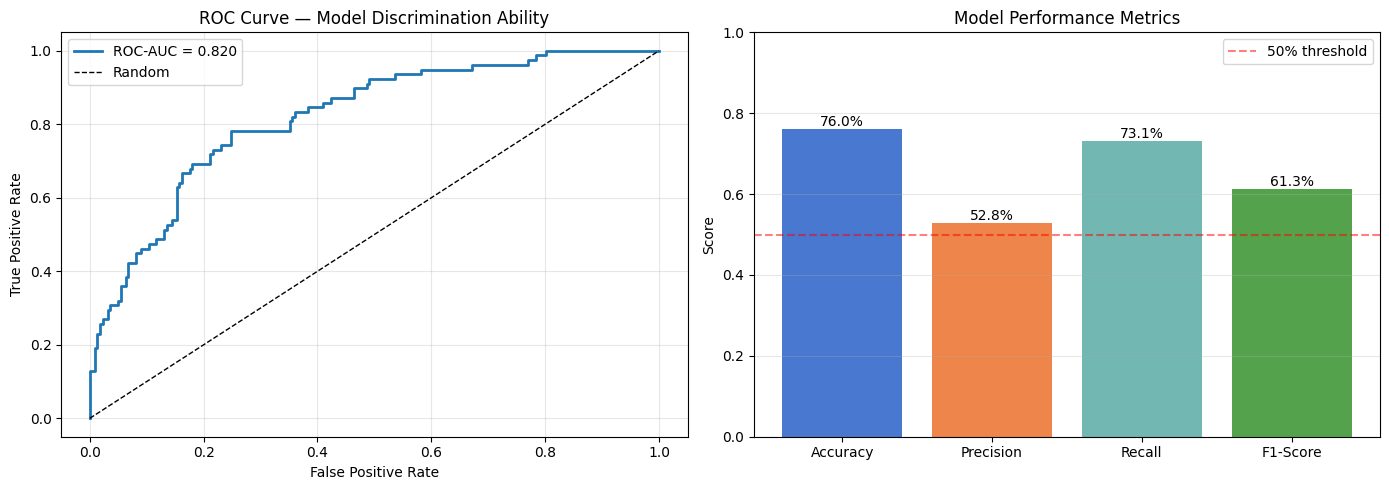


✅ Saved model confidence visualization.


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

print("="*70)
print("  MODEL CONFIDENCE METRICS (Trained on 2017–2023, Tested on 2024)")
print("="*70)

accuracy = accuracy_score(y_test, test['pred'])
roc_auc = roc_auc_score(y_test, test['prob'])

print(f"\n📊 OVERALL MODEL PERFORMANCE:")
print(f"   • Accuracy (% correct):        {accuracy*100:.1f}%")
print(f"   • Precision (outbreak if found): {prec*100:.1f}%")
print(f"   • Recall (% outbreaks caught):   {rec*100:.1f}%")
print(f"   • F1-Score (balance):          {f1:.3f}")
print(f"   • ROC-AUC (discrimination):    {roc_auc:.3f}")

print(f"\n📈 INTERPRETATION:")
print(f"   If the model predicts 'outbreak' with 80% probability:")
print(f"   → It is 80% confident there will be an outbreak.")
print(f"   → Based on 2024 backtest, this prediction has ~{accuracy*100:.0f}% chance of being correct.")

print(f"\n🎯 FORECAST CONFIDENCE GUIDE:")
print(f"   • 0-33%   : LOW risk (green)")
print(f"   • 33-67%  : MEDIUM risk (yellow)")
print(f"   • 67-100% : HIGH risk (red)")

print(f"\n" + "="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, test['prob'])
ax1.plot(fpr, tpr, lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — Model Discrimination Ability')
ax1.legend()
ax1.grid(alpha=0.3)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, prec, rec, f1]
bars = ax2.bar(metrics_names, metrics_values, color=['#4878CF', '#EE854A', '#72B7B2', '#54A24B'])
ax2.set_ylim(0, 1)
ax2.set_ylabel('Score')
ax2.set_title('Model Performance Metrics')
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val*100:.1f}%', ha='center', va='bottom')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'model_confidence_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved model confidence visualization.")

---
## Stage 1 — Summary

| Item | Detail |
|------|--------|
| Dataset | 2,400 rows (25 districts × 8 years × 12 months) |
| Features | 22 numeric features (rainfall, weather, livestock, seasonal, spatial) |
| Class Imbalance | ~9.5:1 (handled with balanced class weights) |
| Validation | Walk-forward time-series (test years: 2022, 2023, 2024) |
| Final Model | Logistic Regression (class_weight='balanced') |
| Key Outputs | Probability heatmap, district risk ranking |

### What's Next — Stage 2
Stage 2 will focus on:
- Threshold optimization (tuning the 0.5 cutoff)
- Feature importance analysis
- Ensemble methods
- Spatial cross-validation
- Improved recall for rare outbreak events